In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
from ugradio.nch import lat as _NCH_LAT, lon as _NCH_LON
from lab3_stuff.lab3_stuff import visibility, rotate_matrix_eq2now, rotate_matrix_eq2top, bessel_it_up

NCH_LAT = np.deg2rad(_NCH_LAT)
NCH_LON = np.deg2rad(_NCH_LON)

%matplotlib widget

In [2]:
WAVELEN = 2.5  # cm

In [3]:
NTIMES = 24000
lat = NCH_LAT
lon = NCH_LON
lsts = np.linspace(0, 2*np.pi, NTIMES, endpoint=False)
ha = lsts - lon

In [4]:
M_eq2nows = rotate_matrix_eq2now(ha)
M_eq2top = rotate_matrix_eq2top(lat)
M = np.einsum('ij,jkt->tik', M_eq2top, M_eq2nows)

In [5]:
sun_eq = np.array([1, 0, 0])  # approximately vernal equinox
sun_top = M @ sun_eq

In [6]:
#baseline = 100 * np.array([15, 3, 0], dtype=float)  # cm
baseline = 100 * np.array([15, 0, 0], dtype=float)  # cm
vis = visibility(baseline, sun_top.T, wavelen=WAVELEN)
vis = np.where(sun_top[:, 2] > 0, vis, 0)

In [29]:
ANG_R = np.deg2rad(0.5 / 2)
ang_r = ANG_R
bessy = bessel_it_up(baseline, sun_top.T, ang_r, wavelen=WAVELEN)
bessy = np.where(sun_top[:, 2] > 0, bessy, 0)
vis_bessy = vis * bessy

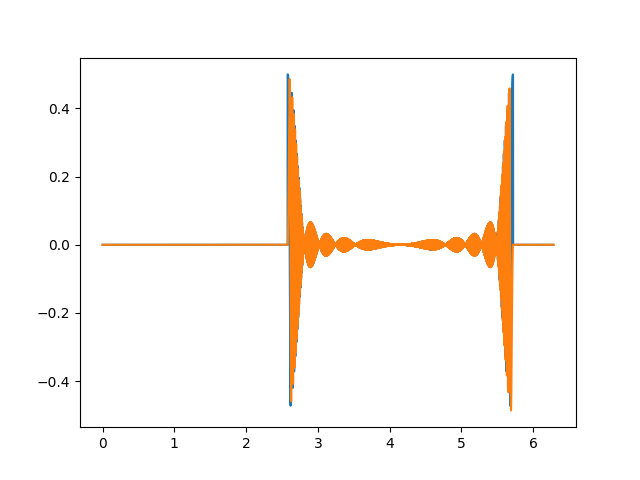

In [30]:
plt.figure()
plt.plot(lsts, vis_bessy.real)
plt.plot(lsts, vis_bessy.imag)
#plt.plot(lsts, bessy)

In [27]:
ff, t, _vis = stft(vis_bessy, fs=24*3600/NTIMES, return_onesided=False)
ff = np.fft.fftshift(ff)
_vis = np.fft.fftshift(_vis, axes=0)

/tmp/ipykernel_160081/476525846.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(np.abs(_vis)), extent=(t[0], t[-1], ff[0], ff[-1]), vmin=-5, cmap='plasma', aspect='auto', interpolation='nearest', origin='lower')


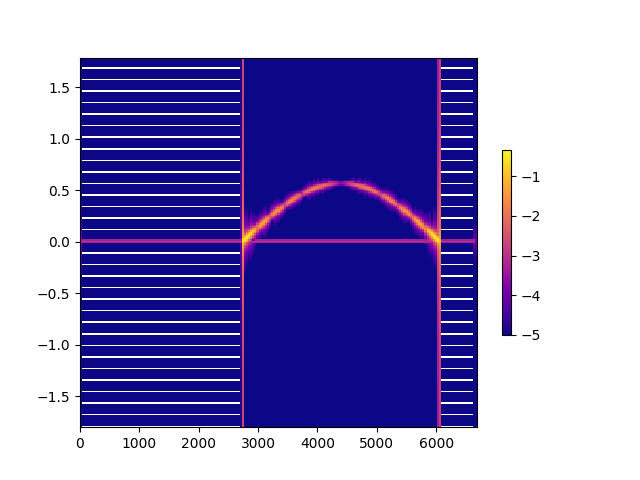

In [28]:
plt.figure()
plt.imshow(np.log10(np.abs(_vis)), extent=(t[0], t[-1], ff[0], ff[-1]), vmin=-5, cmap='plasma', aspect='auto', interpolation='nearest', origin='lower')
plt.colorbar(shrink=0.5)